In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

In [10]:
import numpy as np
from scipy import stats
from sklearn.feature_selection import r_regression, SelectKBest, f_regression
import pandas as pd


# =======================================================================
# (A) Manual — matches the Tut 7 formula exactly (1/N biased estimator)
# =======================================================================
def pearson_corr_manual(a, b):
    """Pearson's r using the biased (1/N) estimator, per the Tut 7 definition."""
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    a_bar, b_bar = a.mean(), b.mean()
    cov = np.mean((a - a_bar) * (b - b_bar))
    sa = np.sqrt(np.mean((a - a_bar) ** 2))
    sb = np.sqrt(np.mean((b - b_bar) ** 2))
    return cov / (sa * sb)


def feature_pearson_scores(X, y):
    """|r| between each column of X (features) and y. Shape (M,). Uses manual r."""
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    return np.array([abs(pearson_corr_manual(X[:, j], y)) for j in range(X.shape[1])])


def select_top_k_features(X, y, k):
    """Return (X_selected, top_idx_desc, abs_scores) ranked by |r| vs y."""
    X = np.asarray(X)
    scores = feature_pearson_scores(X, y)
    top_idx = np.argsort(-scores)[:k]
    return X[:, top_idx], top_idx, scores


# =======================================================================
# (B) Library one-liners — usually the easiest for the exam
# =======================================================================
# 1) scipy.stats.pearsonr(a, b) -> PearsonRResult with .statistic and .pvalue
#    Best when you want a single pair + p-value.
#    r, p = stats.pearsonr(X[:, j], y.ravel())


# 2) sklearn.feature_selection.r_regression(X, y) -> signed r for every column,
#    vectorized. Usually the cleanest for feature selection.
def pearson_r_sklearn(X, y):
    """Signed Pearson r per column of X vs y (via sklearn.r_regression)."""
    return r_regression(np.asarray(X), np.asarray(y).ravel())


# 3) SelectKBest ranks by F-statistic (monotone in |r|), so the top-k subset
#    matches |r| ranking. Returns a transformer ready to .transform() test X.
def select_top_k_sklearn(X, y, k):
    """Top-k feature selection via SelectKBest(f_regression). Same ranking as |r|."""
    skb = SelectKBest(score_func=f_regression, k=k).fit(
        np.asarray(X), np.asarray(y).ravel()
    )
    return skb.transform(X), np.where(skb.get_support())[0], skb


# 4) pandas: a one-liner when your data is already a DataFrame.
def pearson_r_pandas(X, y, feature_names=None):
    """Signed Pearson r per feature as a pandas Series (easy to inspect)."""
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    cols = feature_names or [f"F{i+1}" for i in range(X.shape[1])]
    return (
        pd.DataFrame(np.column_stack([X, y]), columns=cols + ["y"])
        .corr()["y"]
        .drop("y")
    )


# =======================================================================
# Self-check — manual / np / scipy / sklearn all agree (1/N cancels in r)
# =======================================================================
a = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
b = np.array([2.0, 4.0, 6.0, 8.0, 9.0])
print("manual             :", pearson_corr_manual(a, b))
print("np.corrcoef        :", np.corrcoef(a, b)[0, 1])
print("scipy.pearsonr     :", stats.pearsonr(a, b).statistic)
print("sklearn r_regression:", r_regression(a.reshape(-1, 1), b)[0])

manual             : 0.9938837346736189
np.corrcoef        : 0.9938837346736188
scipy.pearsonr     : 0.9938837346736191
sklearn r_regression: 0.9938837346736188


In [11]:
data = np.asarray([
    [0.3510, 2.1812, 0.2415, -0.1096, 0.1544],
    [1.1796, 2.1068, 1.7753, 1.2747, 2.0851],
    [-0.9852, 1.3766, -1.3244, -0.6316, -0.8320],
    [0.2758, 1.4392, -0.4611, 0.6154, 1.0006]])
y = data[-1].reshape(-1, 1)
X = data[:-1].T

X.shape, y.shape


((5, 3), (5, 1))

In [12]:
# Manual scores (biased 1/N, matches tutorial formula exactly)
scores = feature_pearson_scores(X, y)
for i, s in enumerate(scores, start=1):
    r_signed = pearson_corr_manual(X[:, i - 1], y)
    print(f"Feature {i}: r = {r_signed:+.4f}   |r| = {s:.4f}")

# Top-2 selection
X_sel, top_idx, _ = select_top_k_features(X, y, k=2)
print("\nTop-2 feature indices (0-based):", top_idx)
print("=> Features", (top_idx + 1).tolist(), "are the answer to Q1.")
print("Selected X shape:", X_sel.shape)

# --- Cross-checks via other libraries ---
print("\n--- np.corrcoef (rows=vars) ---")
# np.corrcoef uses the unbiased estimator but PEARSON'S r is scale-invariant,
# so the 1/N vs 1/(N-1) factors cancel in numerator and denominator → same r.
print(np.corrcoef(np.hstack([X, y]).T)[:3, 3])  # corr of each feature with y

print("\n--- pd.DataFrame.corr() ---")
df_chk = pd.DataFrame(np.hstack([X, y]), columns=["F1", "F2", "F3", "y"])
print(df_chk.corr()["y"].drop("y"))

print("\n--- scipy.stats.pearsonr ---")
for j in range(3):
    r, p = stats.pearsonr(X[:, j], y.ravel())
    print(f"F{j+1}: r={r:+.4f}  p-value={p:.4f}")

print("\n--- sklearn r_regression (Pearson vector) ---")
print(r_regression(X, y.ravel()))

print("\n--- SelectKBest with f_regression ---")
skb = SelectKBest(score_func=f_regression, k=2).fit(X, y.ravel())
mask = skb.get_support()
print("mask:", mask, " -> selected columns:", np.where(mask)[0])

Feature 1: r = +0.5988   |r| = 0.5988
Feature 2: r = +0.4537   |r| = 0.4537
Feature 3: r = +0.8009   |r| = 0.8009

Top-2 feature indices (0-based): [2 0]
=> Features [3, 1] are the answer to Q1.
Selected X shape: (5, 2)

--- np.corrcoef (rows=vars) ---
[0.59877228 0.45369219 0.80089165]

--- pd.DataFrame.corr() ---
F1    0.598772
F2    0.453692
F3    0.800892
Name: y, dtype: float64

--- scipy.stats.pearsonr ---
F1: r=+0.5988  p-value=0.2860
F2: r=+0.4537  p-value=0.4428
F3: r=+0.8009  p-value=0.1034

--- sklearn r_regression (Pearson vector) ---
[0.59877228 0.45369219 0.80089165]

--- SelectKBest with f_regression ---
mask: [ True False  True]  -> selected columns: [0 2]


In [13]:
from sklearn.preprocessing import PolynomialFeatures
from numpy.linalg import inv
import numpy as np


def polyTx(X, order):
    """Polynomial feature matrix with bias column. Shape: (N, order+1)."""
    return PolynomialFeatures(order).fit_transform(X)


def solvePR(P, y, ridge=False, lamb=0.01):
    """Solve polynomial regression. Auto primal (N>M) or dual (N<M)."""
    if ridge:
        if P.shape[0] > P.shape[1]:  # Primal
            w = inv(P.T @ P + lamb * np.eye(P.shape[1])) @ P.T @ y
        else:  # Dual
            w = P.T @ inv(P @ P.T + lamb * np.eye(P.shape[0])) @ y
    else:
        if P.shape[0] > P.shape[1]:  # Primal
            w = inv(P.T @ P) @ P.T @ y
        else:  # Dual
            w = P.T @ inv(P @ P.T) @ y
    return w


def solveLE_Ridge(X, y, lamb=0.01):
    """Linear regression with Ridge. X must already include bias column."""
    return solvePR(X, y, ridge=True, lamb=lamb)


# Quick test
X_test_poly = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y_test_poly = np.array([[5], [5], [4], [3], [2], [2]])
P = polyTx(X_test_poly, 3)
print("P shape:", P.shape)  # (6, 4): [1, x, x^2, x^3]
w = solvePR(P, y_test_poly)
print("w:", w.ravel())

P shape: (6, 4)
w: [ 2.68935636 -0.37722517  0.01343815  0.00285772]


In [14]:
from sklearn.metrics import mean_squared_error  # alternative to np.mean((...)**2)

# =============================================================================
# SHAPE CONVENTION for polyorder_sweep
# =============================================================================
#   X_train, X_test : (N_tr, d) and (N_te, d)   rows = datapoints
#       For 1-D input with a single scalar feature (Tut 7 Q2), d=1 and you
#       MUST pass a column vector, e.g. np.array([[-10],[-8],...]) not
#       np.array([-10, -8, ...]).  PolynomialFeatures requires 2-D input.
#
#   y_train, y_test : (N_tr, 1) and (N_te, 1)   column vectors
#       A 1-D (N,) array also works, but the weight vector returned will then
#       be 1-D as well. For consistency with the rest of the cheatsheet, we
#       recommend reshaping targets to (N, 1).
#
#   orders : iterable[int]   polynomial degrees to try (e.g. range(1, 7))
#   ridge  : bool            add L2 regularization
#   lamb   : float           ridge strength (only read if ridge=True)
# =============================================================================


def _check_poly_inputs(X_train, y_train, X_test, y_test):
    X_train, X_test = np.asarray(X_train), np.asarray(X_test)
    y_train, y_test = np.asarray(y_train), np.asarray(y_test)
    for name, A in [("X_train", X_train), ("X_test", X_test)]:
        if A.ndim != 2:
            raise ValueError(
                f"{name} must be 2-D with shape (N, d); got shape {A.shape}. "
                f"For scalar input, reshape with .reshape(-1, 1)."
            )
    if X_train.shape[1] != X_test.shape[1]:
        raise ValueError(
            f"X_train has {X_train.shape[1]} feature(s), X_test has {X_test.shape[1]} — must match."
        )
    if y_train.shape[0] != X_train.shape[0]:
        raise ValueError(
            f"len(y_train)={y_train.shape[0]} != X_train.shape[0]={X_train.shape[0]}"
        )
    if y_test.shape[0] != X_test.shape[0]:
        raise ValueError(
            f"len(y_test)={y_test.shape[0]} != X_test.shape[0]={X_test.shape[0]}"
        )
    return X_train, y_train, X_test, y_test


def polyorder_sweep(
    X_train, y_train, X_test, y_test, orders=range(1, 7), ridge=False, lamb=0.0
):
    """
    Fit polynomial regression at each order in `orders` and record train/test MSE.

    Parameters
    ----------
    X_train : (N_tr, d) array  rows = training datapoints (d=1 for Tut 7 Q2)
    y_train : (N_tr, 1) array  training targets (column vector preferred)
    X_test  : (N_te, d) array  rows = test datapoints
    y_test  : (N_te, 1) array  test targets
    orders  : iterable[int]    polynomial degrees, e.g. range(1, 7)
    ridge   : bool             if True, apply ridge (L2) regularization
    lamb    : float            ridge strength (ignored when ridge=False)

    Returns
    -------
    train_mse : (len(orders),) array
    test_mse  : (len(orders),) array
    weights   : list of weight vectors, one per order
                (shapes vary: (order+1, 1) for d=1, more for multi-feature X)

    Notes
    -----
    Uses `polyTx` (PolynomialFeatures) for features and `solvePR` (auto
    primal/dual) for weights — so it picks the right form automatically when
    the polynomial expansion makes the system over- or under-determined.
    """
    X_train, y_train, X_test, y_test = _check_poly_inputs(
        X_train, y_train, X_test, y_test
    )
    orders = list(orders)
    train_mse, test_mse, weights = [], [], []
    for o in orders:
        P_tr = polyTx(X_train, o)
        P_te = polyTx(X_test, o)
        w = solvePR(P_tr, y_train, ridge=ridge, lamb=lamb)
        train_mse.append(np.mean((P_tr @ w - y_train) ** 2))
        test_mse.append(np.mean((P_te @ w - y_test) ** 2))
        weights.append(w)
    return np.array(train_mse), np.array(test_mse), weights


def plot_mse_vs_order(orders, train_mse, test_mse, title="Train vs Test MSE"):
    """
    Quick-look chart of train / test MSE across polynomial orders.

    Parameters
    ----------
    orders    : iterable[int]  x-axis (polynomial degrees)
    train_mse : array-like     y-values for the Train MSE line
    test_mse  : array-like     y-values for the Test  MSE line
    title     : str            plot title
    """
    plt.figure()
    plt.plot(list(orders), train_mse, "o-", label="Train MSE")
    plt.plot(list(orders), test_mse, "s-", label="Test MSE")
    plt.xlabel("Polynomial order")
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()


# Smoke test on the Tut 6 dataset: order 3 should recover the solvePR result exactly.
X_s = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y_s = np.array([[5], [5], [4], [3], [2], [2]])
tr, te, ws = polyorder_sweep(X_s, y_s, X_s, y_s, orders=[1, 2, 3], ridge=False)
print("Smoke train MSE:", np.round(tr, 4))
print("Smoke test  MSE:", np.round(te, 4))

# Shape-check demo: would raise if uncommented (1-D X not allowed).
# bad_X = np.array([-10, -8, -3, -1, 2, 8])        # 1-D — must be (N, 1)
# polyorder_sweep(bad_X, y_s, bad_X, y_s)          # ValueError with a hint

Smoke train MSE: [0.1697 0.1284 0.0063]
Smoke test  MSE: [0.1697 0.1284 0.0063]


order   train MSE    test MSE
    1      2.3071      3.0006
    2      0.0084      0.0296
    3      0.0083      0.0301
    4      0.0017      0.0854
    5      0.0000      1.0548
    6      0.0000     10.7674

Best order (train): 5
Best order (test) : 2


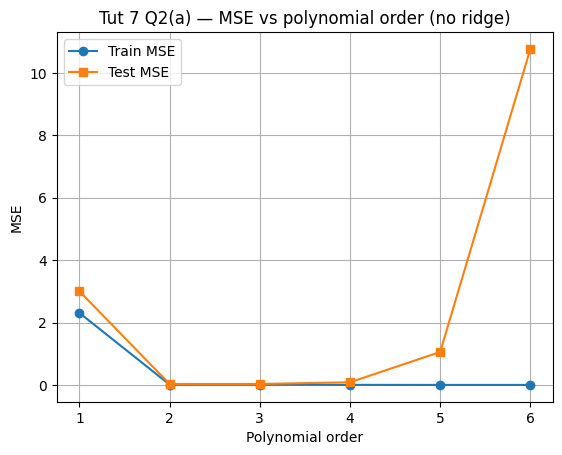

In [15]:
# --- Tutorial 7 Q2 datasets (verbatim from PDF) ---
# Training: 6 points (underlying = quadratic + noise)
X_train_tut7 = np.array([[-10], [-8], [-3], [-1], [2], [7]])
y_train_tut7 = np.array([[4.18], [2.42], [0.22], [0.12], [0.25], [3.09]])

# Test: 10 "clean" points. PDF also lists a trailing {x=-9}->{y=-6} outlier; include below if required.
X_test_tut7 = np.array([[-9], [-7], [-5], [-4], [-2], [1], [4], [5], [6], [9]])
y_test_tut7 = np.array(
    [[3.0], [1.81], [0.80], [0.25], [-0.19], [0.4], [1.24], [1.68], [2.32], [5.05]]
)

# --- Optional: include the trailing outlier from the PDF ({x=-9, y=-6}) ---
# X_test_tut7 = np.vstack([X_test_tut7, [[-9]]])
# y_test_tut7 = np.vstack([y_test_tut7, [[-6.0]]])

orders = range(1, 7)
train_mse, test_mse, _ = polyorder_sweep(
    X_train_tut7, y_train_tut7, X_test_tut7, y_test_tut7, orders=orders, ridge=False
)

print(f'{"order":>5}  {"train MSE":>10}  {"test MSE":>10}')
for o, tr, te in zip(orders, train_mse, test_mse):
    print(f"{o:>5}  {tr:>10.4f}  {te:>10.4f}")

print("\nBest order (train):", list(orders)[np.argmin(train_mse)])
print("Best order (test) :", list(orders)[np.argmin(test_mse)])

plot_mse_vs_order(
    orders,
    train_mse,
    test_mse,
    title="Tut 7 Q2(a) — MSE vs polynomial order (no ridge)",
)

# Expected narrative:
# - Train MSE monotonically decreases with order (more capacity -> can overfit 6 points).
# - Order 5 interpolates the training set exactly -> train MSE = 0.
# - Test MSE minimized near order 2 (matches the quadratic ground truth).
# - Higher orders explode on test -> classic overfitting signature.

order | no-reg train  no-reg test |  ridge train   ridge test
    1 |       2.3071       3.0006 |       2.3586       3.2756
    2 |       0.0084       0.0296 |       0.0085       0.0302
    3 |       0.0083       0.0301 |       0.0084       0.0314
    4 |       0.0017       0.0854 |       0.0018       0.0939
    5 |       0.0000       1.0548 |       0.0007       0.4369
    6 |       0.0000      10.7674 |       0.0002       6.0202


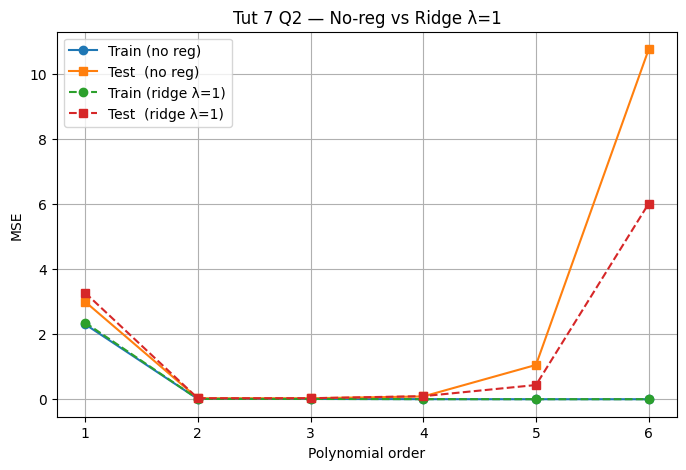

In [16]:
# Repeat the sweep with ridge lambda = 1 on the SAME train/test split
orders = range(1, 7)
tr_noreg, te_noreg, _ = polyorder_sweep(
    X_train_tut7, y_train_tut7, X_test_tut7, y_test_tut7, orders=orders, ridge=False
)
tr_ridge, te_ridge, _ = polyorder_sweep(
    X_train_tut7,
    y_train_tut7,
    X_test_tut7,
    y_test_tut7,
    orders=orders,
    ridge=True,
    lamb=1.0,
)

print(
    f'{"order":>5} | {"no-reg train":>12} {"no-reg test":>12} | {"ridge train":>12} {"ridge test":>12}'
)
for o, a, b, c, d in zip(orders, tr_noreg, te_noreg, tr_ridge, te_ridge):
    print(f"{o:>5} | {a:>12.4f} {b:>12.4f} | {c:>12.4f} {d:>12.4f}")

# Overlay plot
plt.figure(figsize=(8, 5))
ord_list = list(orders)
plt.plot(ord_list, tr_noreg, "o-", label="Train (no reg)")
plt.plot(ord_list, te_noreg, "s-", label="Test  (no reg)")
plt.plot(ord_list, tr_ridge, "o--", label="Train (ridge λ=1)")
plt.plot(ord_list, te_ridge, "s--", label="Test  (ridge λ=1)")
plt.xlabel("Polynomial order")
plt.ylabel("MSE")
plt.title("Tut 7 Q2 — No-reg vs Ridge λ=1")
plt.legend()
plt.grid()
plt.show()

# Observation:
# - No ridge: train MSE drops toward 0 as order rises (overfit);
#   test MSE explodes at high orders.
# - Ridge λ=1: train MSE no longer hits 0 (bias added), but test MSE stays tame.
#   Curves flatten -> regularization trades a little bias for a lot of variance reduction.

Q2 Takeaway points: 

Observe the trained model fits training points better as the number of orders increases.  

Meanwhile, how the model becomes more flexible and twists more sharply to fit the training samples closer. This twisting is a sign of potential overfitting. 

The sign of overfitting can be confirmed with the training/test MSE plot: Starting from order 4, test MSE surges as training MSE remains low.  

When regularization is applied, those sharp twists become slightly more smooth, this is particularly obvious in higher-order models. 

Regularization is helpful in relief overfitting: compare the test MSE of order 5 models with and without regularization: without -> ~1, with-> ~0.5. The model generalizes better on the test set with regularization, this is a sign that regularization improved the model performance and relieved overfitting.  